# Tutorial: your first simulation (Starsim implementation)

This notebook implements the SQ-LNS tutorial model in [**Starsim**](https://starsim.org)
instead of Vivarium. The research question, causal model, and input data are identical to
the [original Vivarium tutorial](index.ipynb) — only the simulation framework differs. Read
the original tutorial's **Design** section first; this notebook picks up at **Implementation**.

The model: a population of Ethiopian children under 2, simulated in weekly steps from
2025–2030, with **diarrheal diseases** as a non-communicable SIS condition, **child wasting**
as a categorical risk that raises diarrhea incidence, and **SQ-LNS** as an intervention that
moves moderately/severely-wasted children who would benefit into the mild category. We compare
a baseline scenario (no SQ-LNS) against full coverage, recording YLDs, YLLs, and deaths.

## How this maps onto Starsim

Starsim provides built-in modules for common pieces, and lets you write custom modules for the
rest. For this model:

* **Background mortality** uses Starsim's built-in **`ss.Deaths`**, which reads age/sex-specific
  mortality rates from a dataframe and applies them per child — exactly the Vivarium strategy.
* **Fertility** is a small **custom** module. Starsim's `ss.Births` makes births proportional to
  the *current* population (a true per-capita crude birth rate), but the Vivarium model uses a
  *constant* inflow tied to the *initial* population size, so we reproduce that.
* **Diarrhea**, **child wasting**, and the **wasting→diarrhea effect** are custom modules:
  Starsim's built-in diseases are *infectious* (they transmit over a contact network), whereas our
  diarrhea is non-communicable (incidence is an individual hazard from data), and Starsim has no
  built-in categorical risk factor or risk-effect. Following the Vivarium structure, the effect is
  its own component that modifies the disease's per-agent susceptibility, rather than being baked
  into the disease.

We pull entity metadata (e.g. the wasting category labels) from **`gbd_mapping`**, the same
package the Vivarium tutorial uses.

## Data

All inputs come from GBD, packaged into the **data artifact** `tutorial.hdf` (built with
`vivarium_inputs` — see the Vivarium tutorial's Data section). We reuse the *exact same
artifact*, so any difference in results comes from the framework, not the data. GBD rates are
annual and piecewise-constant within age bins; the helpers below read draw 0 of each key and
build fast age/sex lookups using the same `np.digitize` age-binning idiom that `ss.Deaths` uses
internally.

In [1]:
import numpy as np
import pandas as pd
import starsim as ss
import gbd_mapping as gm

ARTIFACT = "tutorial.hdf"  # the same artifact the Vivarium tutorial builds with vivarium_inputs
DRAW = "draw_0"
WASTING = gm.risk_factors.child_wasting
CATEGORIES = list(WASTING.categories.to_dict())          # ['cat1','cat2','cat3','cat4']
CAT_LABELS = WASTING.categories.to_dict()
SEX = {"Female": "f", "Male": "m"}


def _draw(df):
    return df[DRAW] if DRAW in getattr(df, "columns", []) else df["value"]


def _by_sex_age(series, extra=None):
    """Reshape an artifact series indexed by (sex, age_start, ..., [extra]) into a dict
    {('f'|'m'[, extra]): (age_edges, values)} for fast np.digitize lookup -- the same
    age-binning idiom ss.Deaths uses internally."""
    df = series.rename("value").reset_index()
    out = {}
    extras = df[extra].unique() if extra else [None]
    for sex_label, sex_key in SEX.items():
        for ex in extras:
            sub = df[df.sex == sex_label]
            if extra:
                sub = sub[sub[extra] == ex]
            sub = sub.sort_values("age_start")
            out[(sex_key, ex) if extra else sex_key] = (sub.age_start.to_numpy(), sub.value.to_numpy())
    return out


def _lookup(table, age, female, extra=None):
    """Per-agent age/sex step-function lookup (np.digitize, the ss.Deaths idiom).

    `extra` keys an additional index level (e.g. wasting category). It may be a single key
    (one table for everyone) or a per-agent array of keys (each agent looked up in its own
    category's table)."""
    age, female = np.asarray(age, float), np.asarray(female)
    out = np.empty(len(age))
    per_agent_extra = extra is not None and not isinstance(extra, str) and np.ndim(extra) > 0
    extra_arr = np.asarray(extra) if per_agent_extra else None
    for sex_key, smask in (("f", female), ("m", ~female)):
        if not smask.any():
            continue
        for key in (np.unique(extra_arr[smask]) if per_agent_extra else [extra]):
            mask = smask & (extra_arr == key) if per_agent_extra else smask
            edges, vals = table[(sex_key, key) if key is not None else sex_key]
            out[mask] = vals[np.clip(np.digitize(age[mask], edges) - 1, 0, len(vals) - 1)]
    return out

/tmp/ipykernel_3088726/3687094278.py:4: DeprecationWarning: 'gbd_mapping' has moved to 'vivarium.gbd_mapping'. Update your imports. This redirect will be removed in a future release.
  import gbd_mapping as gm


The `GBDData` class loads every input the model needs, and also assembles the cause-deleted background mortality dataframe (all-cause minus diarrhea CSMR) and crude birth rate that the demographics modules consume.

In [2]:
class GBDData:
    """Age/sex lookups built from the artifact (draw 0)."""

    def __init__(self, path=ARTIFACT):
        r = lambda k: _draw(pd.read_hdf(path, k))
        self.incidence = _by_sex_age(r("/cause/diarrheal_diseases/incidence_rate"))
        self.remission = _by_sex_age(r("/cause/diarrheal_diseases/remission_rate"))
        self.emr = _by_sex_age(r("/cause/diarrheal_diseases/excess_mortality_rate"))
        self.prevalence = _by_sex_age(r("/cause/diarrheal_diseases/prevalence"))
        self.disability_weight = _by_sex_age(r("/cause/diarrheal_diseases/disability_weight"))
        self.exposure = {c: _by_sex_age(r("/risk_factor/child_wasting/exposure").xs(c, level="parameter"))
                         for c in CATEGORIES}
        rr = r("/risk_factor/child_wasting/relative_risk").xs(
            ("diarrheal_diseases", "incidence_rate"), level=("affected_entity", "affected_measure"))
        self.rr = _by_sex_age(rr, extra="parameter")
        self.paf = _by_sex_age(r("/risk_factor/child_wasting/population_attributable_fraction").xs(
            ("diarrheal_diseases", "incidence_rate"), level=("affected_entity", "affected_measure")))

        # demography
        self.pop_structure = pd.read_hdf(path, "/population/structure")["value"].xs("Ethiopia", level="location")
        births_by_sex = (pd.read_hdf(path, "/covariate/live_births_by_sex/estimate")["value"]
                         .xs("mean_value", level="parameter").groupby("sex").sum())
        self.live_births = float(births_by_sex.sum())
        self.female_birth_fraction = float(births_by_sex["Female"] / births_by_sex.sum())
        t = pd.read_hdf(path, "/population/theoretical_minimum_risk_life_expectancy")["value"].reset_index().sort_values("age_start")
        self.tmrle_edges, self.tmrle_vals = t.age_start.to_numpy(), t.value.to_numpy()

    def tmrle(self, age):
        return self.tmrle_vals[np.clip(np.digitize(age, self.tmrle_edges) - 1, 0, len(self.tmrle_vals) - 1)]

    def cat_proportions(self, age, female):
        return np.column_stack([_lookup(self.exposure[c], age, female) for c in CATEGORIES])

    # ---- inputs for the built-in demographics modules ----
    def background_death_rate_df(self):
        """Cause-deleted all-cause mortality (ACMR - diarrhea CSMR) as a year/sex/age
        dataframe for ss.Deaths. (Children leave the model at age 2 via the AgeOut
        module, so the >2 age bins here are simply never reached.)"""
        acmr = _draw(pd.read_hdf(ARTIFACT, "/cause/all_causes/cause_specific_mortality_rate"))
        csmr = _draw(pd.read_hdf(ARTIFACT, "/cause/diarrheal_diseases/cause_specific_mortality_rate"))
        df = (acmr - csmr).clip(lower=0).rename("mx").reset_index()
        df["Time"] = 2025
        return df[["Time", "sex", "age_start", "mx"]].rename(columns={"sex": "Sex", "age_start": "AgeGrpStart"})

    def crude_birth_rate(self, exit_age=2.0):
        s = self.pop_structure.reset_index()
        s = s[s.age_start < exit_age]
        return self.live_births / float(s["value"].sum())     # births per under-2 person-year

In [3]:
data = GBDData()
data.crude_birth_rate(), len(data.tmrle_edges)   # quick smoke test

(0.5298478975288109, 11001)

## Components

A helper to turn an **annual rate** into a **per-timestep probability** (`1 - exp(-rate·dt)`,
exactly as Vivarium does), then the modules.

In [4]:
DT_YEARS = 7.0 / 365.0


def to_prob(rate, dt=DT_YEARS):
    return 1.0 - np.exp(-np.minimum(np.asarray(rate, float) * dt, 250.0))

### Demographics

Two demographic modules plus the built-in `ss.Deaths` (added in `build_sim` below):

* **`Fertility`** (custom): a constant Poisson inflow of newborns, matching Vivarium's
  `FertilityCrudeBirthRate`. As noted above, `ss.Births` would scale with the current population
  and is unstable against the age-out here, so we write the constant-inflow version.
* **`AgeOut`** (custom): removes children when they reach age 2 (they leave the under-2 model —
  recorded as a removal, not a death).

In [5]:
class Fertility(ss.Demographics):
    """Crude-birth-rate inflow, matching Vivarium's FertilityCrudeBirthRate: a *constant*
    expected number of births per step, tied to the INITIAL simulated population size (not
    the current one), drawn from a Poisson distribution. (Starsim's ss.Births scales births
    with the current population, which differs from this strategy and is unstable against
    age-out here, so we write the constant-inflow version ourselves.)"""
    def __init__(self, data, initial_pop_size, female_fraction, exit_age=2.0, **kw):
        super().__init__(**kw)
        self.mean_births = data.crude_birth_rate(exit_age) * initial_pop_size * DT_YEARS
        self.birth_dist = ss.poisson(lam=self.mean_births)
        self.female_dist = ss.bernoulli(p=float(female_fraction))

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("births", dtype=int, scale=False))

    def step(self):
        n = int(np.atleast_1d(self.birth_dist.rvs(1)).flat[0])
        if n:
            uids = self.sim.people.grow(n)
            self.sim.people.age[uids] = 0.0
            self.sim.people.female[uids] = self.female_dist.rvs(uids)
        self.results.births[self.ti] = n


class AgeOut(ss.Demographics):
    """Remove children when they reach exit_age (they age out of the under-2 model)."""
    def __init__(self, exit_age=2.0, **kw):
        super().__init__(**kw)
        self.exit_age = exit_age

    def step(self):
        ppl = self.sim.people
        aged_out = ppl.auids[ppl.age[ppl.auids] >= self.exit_age]
        if len(aged_out):
            ppl.request_removal(aged_out)

### Child wasting

Each child gets a fixed propensity ~U(0,1), mapped each step to a GBD wasting category from the
age/sex-specific category proportions (so the category can change as the child ages) — Vivarium's
polytomous-risk assignment. Category labels come from `gbd_mapping` (`CAT_LABELS`).

In [6]:
class Wasting(ss.Module):
    """Polytomous child-wasting exposure: a fixed per-child propensity mapped to a GBD
    category each step from the age/sex-specific category proportions."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data
        self.define_states(
            ss.FloatArr("propensity", default=ss.uniform()),
            ss.FloatArr("cat", default=len(CATEGORIES) - 1),   # default = unexposed
        )

    def baseline_category(self, uids):
        age, fem = self.sim.people.age[uids], self.sim.people.female[uids]
        cumsum = np.cumsum(self.data.cat_proportions(age, fem), axis=1)
        return np.clip((cumsum < np.asarray(self.propensity[uids])[:, None]).sum(axis=1), 0, len(CATEGORIES) - 1)

    def step(self):
        uids = self.sim.people.auids
        self.cat[uids] = self.baseline_category(uids).astype(float)

### The SQ-LNS intervention

Among covered children who are moderately/severely wasted (cat1/cat2), 13% benefit and move up to
mild (cat3). This is the intervention, but we implement it as a plain `ss.Module` rather than an
`ss.Intervention` for a loop-ordering reason: it needs to run right after `Wasting` (to modify the
freshly-computed category) and *before* the wasting effect reads it. Starsim runs the `custom`
phase before connectors, so listing `Wasting` then `SQLNS` as custom modules gives exactly that
order. (As an `ss.Intervention` it would run *after* connectors, too late for the effect to see it.)

In [7]:
class SQLNS(ss.Module):
    """The SQ-LNS intervention: shift moderately/severely wasted children who are covered and
    would benefit (13%) up to the mild-wasting category. Implemented as a plain module that
    runs in the `custom` phase (right after `Wasting` sets the baseline category and before the
    `WastingEffect` connector reads it), so the effect sees the up-to-date post-intervention
    exposure with no lag."""
    def __init__(self, coverage=0.0, benefit=0.13, **kw):
        super().__init__(**kw)
        self.define_states(
            ss.BoolArr("covered", default=ss.bernoulli(p=coverage)),
            ss.BoolArr("would_benefit", default=ss.bernoulli(p=benefit)),
        )

    def step(self):
        wasting = self.sim.custom["wasting"]
        uids = self.sim.people.auids
        cat = wasting.cat[uids]
        shift = ((cat == 0) | (cat == 1)) & np.asarray(self.covered[uids]) & np.asarray(self.would_benefit[uids])
        cat[shift] = 2.0
        wasting.cat[uids] = cat

### The effect of wasting on diarrhea

This is the analogue of Vivarium's separate `RiskEffect` component, implemented as an **`ss.Connector`**
(its job is to link the wasting risk to the disease). Rather than baking the risk into the disease,
`Diarrhea` exposes a per-agent **`rel_sus`** multiplier (default 1.0), and this connector sets it to
`RR(category) × (1 − PAF)` — exactly the modification Vivarium applies to the incidence-rate pipeline.
Keeping it separate means the disease knows nothing about wasting, and more risk effects could be
added without touching it.

Connectors run after the `custom` phase (where `Wasting` and `SQLNS` have set the post-intervention
category) and before the disease step, so the effect reads the up-to-date exposure — just as
Vivarium's `RiskEffect` reads the SQLNS-modified exposure pipeline. The per-agent relative-risk
lookup uses the vectorised `_lookup(..., extra=<per-agent categories>)`.

In [8]:
class WastingEffect(ss.Connector):
    """Effect of child wasting on diarrhea incidence -- the analogue of Vivarium's RiskEffect.
    A connector (it links the wasting risk to the disease) that sets the disease's per-agent
    relative susceptibility to RR(category) x (1 - PAF), the same modification Vivarium applies
    to the incidence_rate. Connectors run after the `custom` phase (where Wasting and SQLNS set
    the post-intervention category) and before the disease step, so it reads the up-to-date
    exposure (just as Vivarium's RiskEffect reads the SQLNS-modified exposure pipeline)."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data

    def step(self):
        sim = self.sim
        uids = sim.people.auids
        age, fem = sim.people.age[uids], sim.people.female[uids]
        category = np.array(CATEGORIES)[sim.custom["wasting"].cat[uids].astype(int)]
        rr = _lookup(self.data.rr, age, fem, extra=category)
        paf = _lookup(self.data.paf, age, fem)
        sim.diseases.diarrhea.rel_sus[uids] = rr * (1.0 - paf)

### Diarrheal diseases (non-communicable SIS)

Susceptible children acquire diarrhea at the GBD incidence rate scaled by their `rel_sus` (set by
the wasting effect above); infected children remit at the remission rate and face excess mortality.
No transmission between children. The module seeds initial cases at the GBD prevalence and records
YLDs (disability weight × person-time) each step.

In [9]:
class Diarrhea(ss.Disease):
    """Non-communicable SIS diarrhea: acquisition from the GBD incidence rate, remission, and
    excess mortality among the infected. No transmission. Risk factors modify acquisition
    through the per-agent `rel_sus` multiplier (default 1), set by separate effect modules --
    analogous to Vivarium's value pipeline on the incidence_rate."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data
        self.define_states(
            ss.BoolState("infected", label="Has diarrhea"),
            ss.FloatArr("rel_sus", default=1.0, label="Relative susceptibility (set by risk effects)"),
        )
        self.acq = ss.bernoulli(p=self._p_acquire)
        self.rem = ss.bernoulli(p=self._p_remit)
        self.death = ss.bernoulli(p=self._p_excess_death)

    @property
    def susceptible(self):
        return ~self.infected

    def init_post(self):
        super().init_post()
        uids = self.sim.people.auids
        p0 = _lookup(self.data.prevalence, self.sim.people.age[uids], self.sim.people.female[uids])
        seed = ss.bernoulli(p=p0)
        seed.init(sim=self.sim, module=self, force=True)
        self.infected[seed.filter(uids)] = True

    def _p_remit(self, sim, uids):
        return to_prob(_lookup(self.data.remission, sim.people.age[uids], sim.people.female[uids]))

    def _p_excess_death(self, sim, uids):
        return to_prob(_lookup(self.data.emr, sim.people.age[uids], sim.people.female[uids]))

    def _p_acquire(self, sim, uids):
        age, fem = sim.people.age[uids], sim.people.female[uids]
        incidence = _lookup(self.data.incidence, age, fem) * np.asarray(self.rel_sus[uids])
        return to_prob(incidence)

    def step_state(self):
        self._susceptible_at_start = self.susceptible.uids       # one transition per step
        inf = self.infected.uids                                 # prevalent cases this step
        if len(inf):
            self.sim.people.request_death(self.death.filter(inf))  # excess mortality on prevalent cases
            self.infected[self.rem.filter(inf)] = False            # remission

    def step(self):
        sus = self._susceptible_at_start
        if len(sus):
            self.infected[self.acq.filter(sus)] = True           # acquisition

    def step_die(self, uids):
        self.infected[uids] = False

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("prevalence", dtype=float, scale=False),
                            ss.Result("ylds", dtype=float, scale=False))

    def update_results(self):
        super().update_results()
        ppl, inf = self.sim.people, self.infected.uids
        n = len(ppl.auids)
        self.results.prevalence[self.ti] = len(inf) / n if n else 0.0
        self.results.ylds[self.ti] = float(_lookup(self.data.disability_weight, ppl.age[inf], ppl.female[inf]).sum()) * DT_YEARS if len(inf) else 0.0

### Observing mortality burden

Deaths come from two sources — background (`ss.Deaths`) and diarrhea excess mortality — so a small
analyzer records **YLLs** (theoretical-minimum-risk life expectancy at the age of death) and the
death count across *all* deaths each step.

In [10]:
class BurdenObserver(ss.Analyzer):
    """Record YLLs (TMRLE at age of death) for every death this step, from any cause."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("ylls", dtype=float, scale=False),
                            ss.Result("deaths", dtype=int, scale=False))

    def step(self):
        ppl = self.sim.people
        died = (ppl.ti_dead == self.sim.ti).uids
        self.results.deaths[self.ti] = len(died)
        self.results.ylls[self.ti] = float(self.data.tmrle(ppl.age[died]).sum()) if len(died) else 0.0

## Configuration

`build_sim` assembles everything: the under-2 starting population (drawn from the GBD age
structure), the custom `Fertility` + built-in `ss.Deaths` + `AgeOut` demographics, the `Diarrhea`
disease, the `Wasting` exposure, the `SQLNS` intervention, and the `BurdenObserver`. Weekly steps,
2025–2030, `use_aging=True`. The `coverage` argument selects baseline (0) vs intervention (1); the
same `seed` gives both scenarios common random numbers.

In [11]:
def build_sim(coverage=0.0, n_agents=500_000, seed=0, data=None, exit_age=2.0):
    if data is None:
        data = GBDData()
    struct = data.pop_structure.reset_index()
    u2 = struct[struct.age_start < exit_age].groupby("age_start")["value"].sum()
    age_data = pd.concat([pd.DataFrame({"age": u2.index, "value": u2.values}),
                          pd.DataFrame({"age": [exit_age], "value": [0.0]})], ignore_index=True)
    # Initial under-2 cohort: sex from the existing under-2 population's sex ratio.
    init_female_frac = struct[(struct.age_start < exit_age) & (struct.sex == "Female")]["value"].sum() / struct[struct.age_start < exit_age]["value"].sum()
    people = ss.People(n_agents=n_agents, age_data=age_data)
    people.female.default = ss.bernoulli(p=float(init_female_frac))

    death_meta = dict(data_cols=dict(year="Time", sex="Sex", age="AgeGrpStart", value="mx"),
                      sex_keys={"Female": "f", "Male": "m"})
    return ss.Sim(
        people=people,
        demographics=[
            # Newborn sex from the live-births sex ratio (live_births_by_sex), not the population structure.
            Fertility(data, initial_pop_size=n_agents, female_fraction=data.female_birth_fraction, exit_age=exit_age, name="fertility"),
            ss.Deaths(death_rate=data.background_death_rate_df(), rate_units=1, metadata=death_meta),
            AgeOut(exit_age=exit_age, name="ageout"),
        ],
        diseases=[Diarrhea(data, name="diarrhea")],
        # Wasting sets the baseline category, then SQLNS modifies it (in list order) -- both in
        # the custom phase, before the connector reads the result.
        custom=[Wasting(data, name="wasting"), SQLNS(coverage=coverage, name="sqlns")],
        connectors=[WastingEffect(data, name="wasting_effect")],
        analyzers=[BurdenObserver(data, name="burden")],
        networks=[],
        start=ss.date("2025-01-01"), stop=ss.date("2030-12-31"), dt=ss.days(7),
        rand_seed=seed, pars=dict(use_aging=True), verbose=0,
    )

We build and initialise the two scenarios (no time has passed yet). At 500,000 children each scenario takes a few minutes.

In [12]:
POPULATION_SIZE = 500_000          # reduce for faster runs
sim_baseline = build_sim(coverage=0.0, n_agents=POPULATION_SIZE, data=data)
sim_intervention = build_sim(coverage=1.0, n_agents=POPULATION_SIZE, data=data)
sim_baseline.init()
sim_intervention.init()

Sim(n=500000; 2025.01.01—2030.12.31; demographics=fertility, deaths, ageout; diseases=diarrhea; connectors=wasting_effect; analyzers=burden)

## Verification and validation

Let's inspect the starting population. `get_simulants` returns a tidy table; `refresh_wasting`
recomputes the effective wasting category (baseline assignment + SQ-LNS effect) so we can see the
intervention before any time passes.

In [13]:
def refresh_wasting(sim):
    sim.custom["wasting"].step()        # assign baseline category
    sim.custom["sqlns"].step()          # apply SQ-LNS (no-op at 0% coverage)

def get_simulants(sim):
    ppl = sim.people
    uids = ppl.auids
    cat = np.asarray(sim.custom["wasting"].cat[uids]).astype(int)
    return pd.DataFrame({
        "age": np.asarray(ppl.age[uids]),
        "sex": np.where(np.asarray(ppl.female[uids]), "Female", "Male"),
        "wasting": pd.Series(cat).map({i: CAT_LABELS[c] for i, c in enumerate(CATEGORIES)}).values,
        "diarrhea": np.where(np.asarray(sim.diseases.diarrhea.infected[uids]), "infected", "susceptible"),
        "covered_by_sqlns": np.asarray(sim.custom["sqlns"].covered[uids]),
    }, index=np.asarray(uids))

refresh_wasting(sim_baseline)
refresh_wasting(sim_intervention)
get_simulants(sim_baseline)

,age,sex,wasting,diarrhea,covered_by_sqlns
0,0.053853,Male,Unexposed,susceptible,False
1,1.542036,Male,Unexposed,susceptible,False
2,0.366872,Male,Unexposed,susceptible,False
3,1.553843,Female,Unexposed,susceptible,False
4,0.272702,Male,Wasting Between -2 SD and -1 SD (post-ensemble),susceptible,False
...,...,...,...,...,...
499995,0.422553,Female,Unexposed,susceptible,False
499996,0.372884,Male,Wasting Between -2 SD and -1 SD (post-ensemble),susceptible,False
499997,0.694445,Male,Wasting Between -2 SD and -1 SD (post-ensemble),susceptible,False
499998,0.360887,Female,Wasting Between -3 SD and -2 SD (post-ensemble),susceptible,False


Validation against the GBD inputs — wasting distribution (about two-thirds unexposed) and diarrhea prevalence (a percent or two):

In [14]:
baseline = get_simulants(sim_baseline)
print("Wasting distribution:\n", baseline.wasting.value_counts(normalize=True).round(4))
print("\nDiarrhea prevalence:", round((baseline.diarrhea == "infected").mean(), 4))

Wasting distribution:
 wasting
Unexposed                                          0.6795
Wasting Between -2 SD and -1 SD (post-ensemble)    0.2058
Wasting Between -3 SD and -2 SD (post-ensemble)    0.0832
Severe Wasting, < -3 SD (post-ensemble)            0.0315
Name: proportion, dtype: float64

Diarrhea prevalence: 0.0149


Common random numbers: the two scenarios start identical and differ only where SQ-LNS acts.

In [15]:
intervention = get_simulants(sim_intervention)
print("Same ages? ", np.allclose(baseline.age, intervention.age),
      "| Same diarrhea? ", (baseline.diarrhea == intervention.diarrhea).all())
moved = (baseline.wasting != intervention.wasting)
print(f"Children whose wasting category SQ-LNS changed: {moved.sum()}")
intervention[moved].join(baseline[["wasting"]], rsuffix="_baseline")[["wasting_baseline", "wasting"]].head()

Same ages?  True | Same diarrhea?  True
Children whose wasting category SQ-LNS changed: 7465


,wasting_baseline,wasting
6,Wasting Between -3 SD and -2 SD (post-ensemble),Wasting Between -2 SD and -1 SD (post-ensemble)
25,"Severe Wasting, < -3 SD (post-ensemble)",Wasting Between -2 SD and -1 SD (post-ensemble)
29,"Severe Wasting, < -3 SD (post-ensemble)",Wasting Between -2 SD and -1 SD (post-ensemble)
79,Wasting Between -3 SD and -2 SD (post-ensemble),Wasting Between -2 SD and -1 SD (post-ensemble)
271,Wasting Between -3 SD and -2 SD (post-ensemble),Wasting Between -2 SD and -1 SD (post-ensemble)


### Running the simulations
Run both scenarios to the end of 2030. We use `ss.MultiSim` to run the two scenarios in parallel — one OS process per sim — so on a multi-core machine the pair finishes in roughly the time of a single scenario rather than the sum of both. (Starsim pickles each sim out to its worker process and returns the completed copy, which is why we reassign `sim_baseline, sim_intervention` from `msim.sims` below.)

In [16]:
%%time
# Run both scenarios in parallel with ss.MultiSim: one process per sim.
msim = ss.MultiSim(sims=[sim_baseline, sim_intervention])
msim.run()
sim_baseline, sim_intervention = msim.sims   # completed sims (with results) come back here
print("Final dates:", sim_baseline.t.now(), sim_intervention.t.now())

Final dates: 2030.12.25 2030.12.25
CPU times: user 4.51 s, sys: 1.32 s, total: 5.83 s
Wall time: 2min 38s


Sanity check: the population should stay roughly stable (births balancing age-outs and deaths).

In [17]:
print("Baseline population start/end:", int(sim_baseline.results.n_alive[0]), int(sim_baseline.results.n_alive[-1]))
print("Mean diarrhea prevalence over the run:", round(float(np.mean(sim_baseline.diseases.diarrhea.results.prevalence)), 4))

Baseline population start/end: 504777 504900
Mean diarrhea prevalence over the run: 0.0258


### Built-in plots

Because every module declared its outputs with `define_results`, Starsim records them all as time
series and can plot the entire simulation in a single call — a nice perk of the framework, with no
manual plotting code. Each panel below comes straight from a module's results (births from
`Fertility`, prevalence/YLDs from `Diarrhea`, YLLs/deaths from the observer, population from
`ss.Deaths`/`People`, etc.).

Figure(933.333x700)


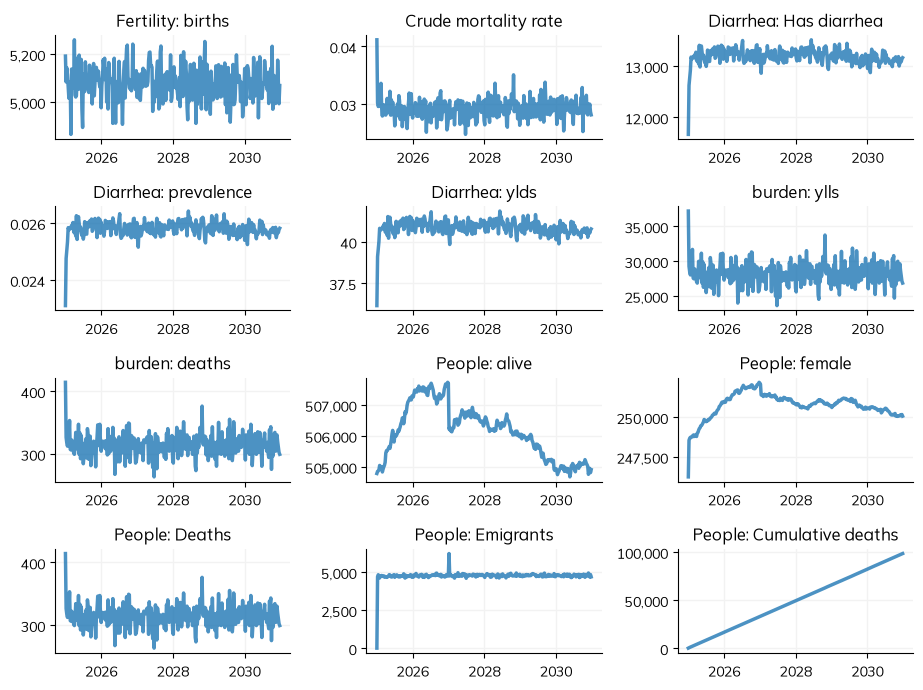

In [18]:
sim_baseline.plot()

You can also plot a single module — e.g. `sim_baseline.diseases.diarrhea.plot()` for just the
diarrhea outputs, or `sim_baseline.people.plot()` for the population's age/sex structure. (For
comparing scenarios on shared axes, Starsim's `ss.MultiSim` can run and overlay several sims at once.)

## Analyzing results

YLDs come from the `Diarrhea` module; YLLs and deaths from the `BurdenObserver`. We sum each over
the run for both scenarios and take the difference (burden averted by SQ-LNS).

In [19]:
def totals(sim):
    ylds = float(np.sum(sim.diseases.diarrhea.results.ylds))
    ylls = float(np.sum(sim.analyzers.burden.results.ylls))
    deaths = int(np.sum(sim.analyzers.burden.results.deaths))
    return pd.Series({"YLDs": ylds, "YLLs": ylls, "deaths": deaths, "DALYs": ylds + ylls})

results = pd.DataFrame({"baseline": totals(sim_baseline), "intervention": totals(sim_intervention)})
results["averted"] = results["baseline"] - results["intervention"]
results

,baseline,intervention,averted
YLDs,1.278361e+04,1.277874e+04,4.865980
YLLs,8.834336e+06,8.834067e+06,268.898798
deaths,9.851100e+04,9.850800e+04,3.000000
DALYs,8.847120e+06,8.846846e+06,273.764777


SQ-LNS only affects diarrhea *incidence*, so the YLD difference is the clearest signal, with a knock-on reduction in diarrhea deaths. The differences are small in our simulated population — we scale them to the real population next.

### Scaling to the real population

Scale by the ratio of the true Ethiopian under-2 population to our simulated population.

In [20]:
simulated_population_size = POPULATION_SIZE
struct = data.pop_structure.reset_index()
real_population_size = struct[struct.age_start < 2.0]["value"].sum()
scaling_factor = real_population_size / simulated_population_size
scaled = results["averted"] * scaling_factor
print(f"Scaling factor: {scaling_factor:,.1f}")
print(f"\nPredicted YLDs averted:  {scaled['YLDs']:,.0f}")
print(f"Predicted YLLs averted:  {scaled['YLLs']:,.0f}")
print(f"Predicted DALYs averted in Ethiopia (2025-2030): {scaled['DALYs']:,.0f}")

Scaling factor: 13.2

Predicted YLDs averted:  64
Predicted YLLs averted:  3,551
Predicted DALYs averted in Ethiopia (2025-2030): 3,615


### How precise is this estimate?

Treat the DALYs-averted figure with caution: it is dominated by **averted deaths**, and only a
handful of deaths differ between scenarios, so it carries a lot of Monte Carlo noise. The original
Vivarium tutorial makes the same point. The **YLD-averted** component (the direct effect of SQ-LNS
on diarrhea disability, spread across the whole population) is the stable, reproducible signal; the
**YLL/deaths-averted** component swings by ~1,000+ scaled DALYs per averted death. A precise
estimate would average over many seeds and GBD draws.

## Conclusion

We reproduced the Vivarium SQ-LNS tutorial in Starsim, reading the same GBD artifact and the same
modeling strategy. Where Starsim has a matching built-in we used it (`ss.Deaths` for background
mortality); where the strategy differs (`ss.Births` scales with current population) or there is no
built-in (non-communicable disease, categorical risk), we wrote short custom modules. Both models
consume identical inputs and agree to within Monte Carlo noise on the well-determined quantities
(absolute deaths/YLLs/YLDs within a few percent; see the companion V&V notebook).

A real analysis would be more complex — multiple causal pathways, deeper V&V, and uncertainty
quantification across draws and seeds.